In [1]:
##3-Rushda Qureshi-2503951-msbawe2

In [3]:
# 1. Setup
import pandas as pd

In [4]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
sns.set_style("whitegrid")

In [12]:
# Load both datasets (note the ';' delimiter)
red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

In [13]:
# Add a 'type' column to keep track of the wine variety
red_wine['type'] = 'red'
white_wine['type'] = 'white'

In [14]:
# Combine into one dataframe
df = pd.concat([red_wine, white_wine], ignore_index=True)

In [16]:
# Save the combined dataset
df.to_csv('Combined_Wine_Quality.csv', index=False)
print("Files combined successfully. Shape:", df.shape)

Files combined successfully. Shape: (6497, 13)



Descriptive Statistics:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.700000          0.400000     0.390000        8.100000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  6497.000000          6497.000000           6497.000000  6497.000000   
mean      0.056034            30.525319            115.744574     0.994697   
std       0.035034            17.749400             56.521855     0.002999   
min       0.009000    

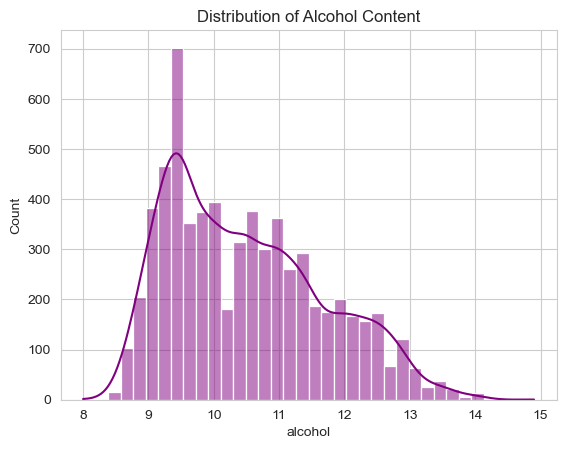

In [17]:
# 3. Exploratory Data Analysis (EDA)
# 4. Univariate analysis
print("\nDescriptive Statistics:\n", df.describe())
sns.histplot(df['alcohol'], kde=True, color='purple')
plt.title('Distribution of Alcohol Content')
plt.show()

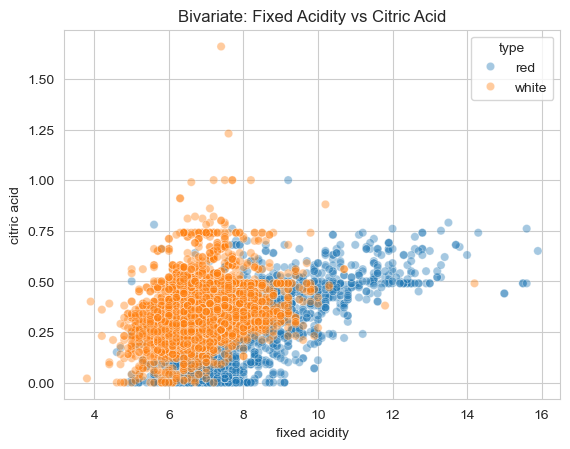

In [18]:
# 5. Bivariate analysis: Fixed Acidity vs Citric Acid (Strong correlation)
sns.scatterplot(x='fixed acidity', y='citric acid', hue='type', data=df, alpha=0.4)
plt.title('Bivariate: Fixed Acidity vs Citric Acid')
plt.show()

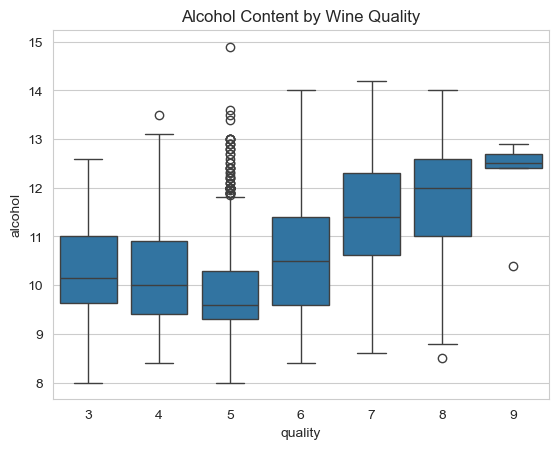

In [19]:
# Box Plot: Alcohol vs Quality
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol Content by Wine Quality')
plt.show()

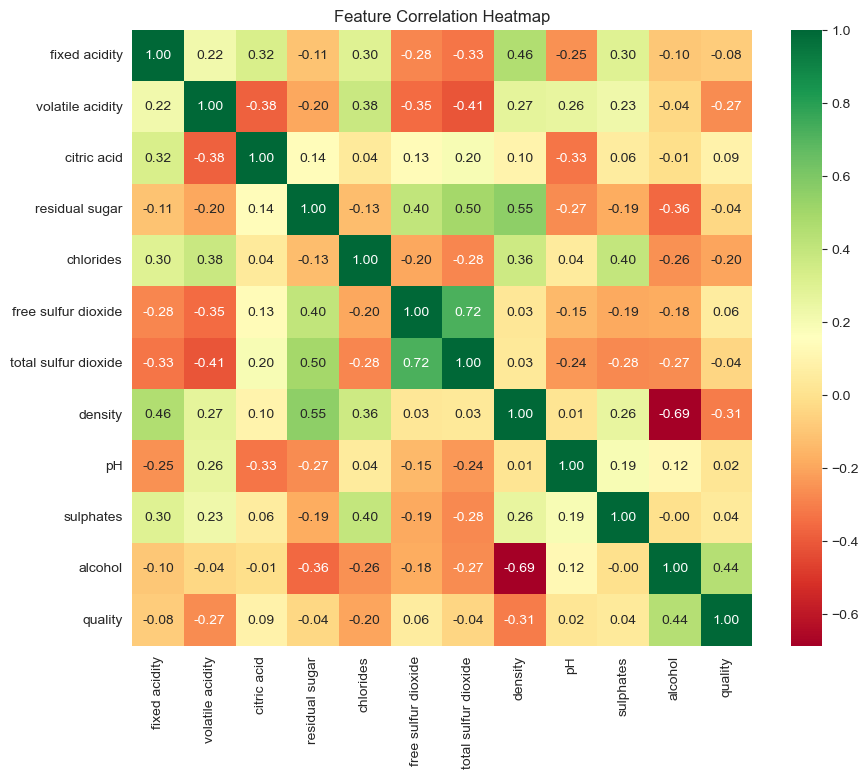

In [20]:
# 6. Correlation matrix and heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [21]:
# 7. Class imbalance (Quality distribution)
print("\nQuality Score Distribution:\n", df['quality'].value_counts(normalize=True).sort_index())


Quality Score Distribution:
 quality
3    0.004618
4    0.033246
5    0.329075
6    0.436509
7    0.166077
8    0.029706
9    0.000770
Name: proportion, dtype: float64


In [22]:
# 8. Outlier detection (Z-scores for Residual Sugar)
z_sugar = np.abs((df['residual sugar'] - df['residual sugar'].mean()) / df['residual sugar'].std())
print(f"Residual Sugar Outliers (Z > 3): {(z_sugar > 3).sum()}")

Residual Sugar Outliers (Z > 3): 26


In [23]:
# 10. Feature Engineering
# 12. New Features: Alcohol/Density Ratio & High Quality Flag
df['alcohol_density_ratio'] = df['alcohol'] / df['density']
df['high_quality'] = (df['quality'] >= 7).astype(int)

In [24]:
# 13. Encode categorical 'type'
df['type_red'] = (df['type'] == 'red').astype(int)

In [25]:
# 15. Train/Test Split (For Regression on Quality)
X = df.drop(['quality', 'type', 'high_quality'], axis=1)
y = df['quality']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 14. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# 18. Cross-Validation (RMSE)
lin_reg = LinearRegression()
cv_mse = -cross_val_score(lin_reg, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"CV Root Mean Squared Error (RMSE): {np.sqrt(cv_mse.mean()):.4f}")

CV Root Mean Squared Error (RMSE): 0.7337


In [29]:
# 19. Linear Regression Model
lin_reg.fit(X_train_scaled, y_train)
y_pred = lin_reg.predict(X_test_scaled)

In [30]:
# 20. Evaluation
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

R-squared: 0.2720
MSE: 0.5377


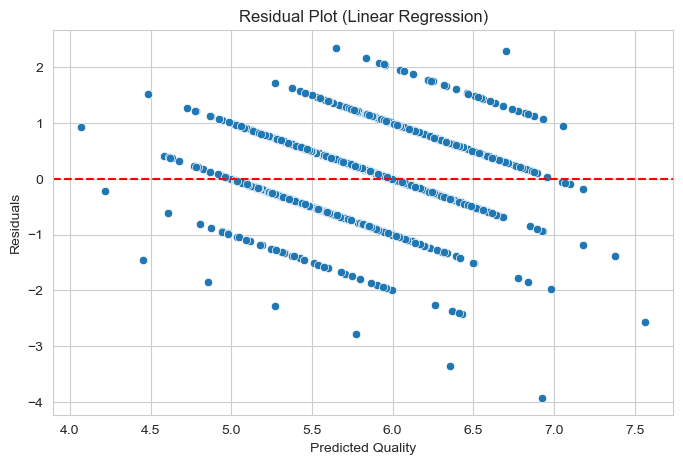

In [31]:
# Residual Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=(y_test - y_pred))
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (Linear Regression)')
plt.xlabel('Predicted Quality')
plt.ylabel('Residuals')
plt.show()

In [32]:
# 22. Interpretation
coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lin_reg.coef_})
print("\nTop Contributing Features:\n", coeffs.sort_values(by='Coefficient', ascending=False))


Top Contributing Features:
                   Feature  Coefficient
11  alcohol_density_ratio    12.293891
3          residual sugar     0.270458
12               type_red     0.134538
0           fixed acidity     0.111341
9               sulphates     0.110899
5     free sulfur dioxide     0.102646
8                      pH     0.081261
7                 density     0.050337
2             citric acid    -0.015575
4               chlorides    -0.021263
6    total sulfur dioxide    -0.093312
1        volatile acidity    -0.250132
10                alcohol   -11.783186
